# Proximal Policy Optimization (PPO)

This notebook trains a PPO agent on LunarLander-v3 using Stable-Baselines3,
following the same environment setup and evaluation methodology as the DQN notebook.

## 1. Gymnasium Environment Setup

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

In [2]:
import sys
from pathlib import Path

SRC_PATH = Path.cwd().parent
sys.path.insert(0, str(SRC_PATH))

In [3]:
# Initialize environment (same settings as DQN notebook)
env = gym.make(
    "LunarLander-v3",
    continuous=False,
    render_mode="rgb_array",
    gravity=-10.0,
    enable_wind=True,
    wind_power=10.0,
    turbulence_power=1.0,
)

n_actions = env.action_space.n
state, info = env.reset()
n_observations = len(state)

print(f"Number of possible actions: {n_actions}")
print(f"Number of state observations: {n_observations}")
print(f"Initial state: {state}")

Number of possible actions: 4
Number of state observations: 8
Initial state: [ 0.00632133  1.4119204   0.6407239   0.04444421 -0.00774099 -0.15340379
  0.          0.        ]


/home/pnguyen/Workspace/Northeastern_University/ReinforcementLearning_CS_5180/rf_venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 2. PPO Overview

Because PPO is on-policy, it does **not** use a replay buffer. Instead, it:
1. Collects a batch of trajectories by running the current policy in the environment
2. Computes advantages using Generalized Advantage Estimation (GAE)
3. Updates the policy for several epochs on that batch, clipping the objective to prevent too-large updates
4. Throws away the data and collects fresh rollouts

We use Stable-Baselines3's well-tested implementation rather than writing from scratch,
as specified in the project proposal.

## 3. Install and Import Stable-Baselines3

In [4]:
# Uncomment the line below if stable-baselines3 is not installed
# !pip install stable-baselines3[extra]

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor

## 4. PPO Training Config

To match the DQN notebook's style, we define a config dataclass.

**Key hyperparameters explained:**
- `n_steps`: Number of environment steps collected per rollout before each update (DQN has no equivalent — it updates every step from replay)
- `batch_size`: Mini-batch size for each SGD epoch within a PPO update
- `n_epochs`: How many passes over the collected rollout data per update (DQN does 1 gradient step per env step)
- `learning_rate`: Same concept as DQN, controls step size
- `gamma`: Discount factor (same as DQN, 0.99)
- `gae_lambda`: Controls bias-variance tradeoff in advantage estimation (no DQN equivalent)
- `clip_range`: The ε in the clipped surrogate objective — how far the new policy can deviate from the old one
- `ent_coef`: Entropy bonus coefficient — encourages exploration (replaces ε-greedy)
- `vf_coef`: Weight of value function loss relative to policy loss
- `max_grad_norm`: Gradient clipping (same concept as DQN's `grad_clip_norm`)

In [5]:
from dataclasses import dataclass


@dataclass
class PPOTrainingConfig:
    seed: int = 42
    total_timesteps: int = 300_000  # total env steps for training
    n_steps: int = 2048             # steps per rollout collection
    batch_size: int = 64            # mini-batch size for SGD updates
    n_epochs: int = 10              # SGD epochs per rollout
    learning_rate: float = 3e-4     # SB3 default for PPO
    gamma: float = 0.99             # discount factor (same as DQN)
    gae_lambda: float = 0.95        # GAE lambda
    clip_range: float = 0.2         # PPO clipping parameter
    ent_coef: float = 0.01          # entropy bonus (encourages exploration)
    vf_coef: float = 0.5            # value function loss weight
    max_grad_norm: float = 0.5      # gradient clipping
    net_arch: list = None           # network architecture
    eval_episodes: int = 5          # evaluation episodes (same as DQN)
    max_steps_per_episode: int = 1000

    def __post_init__(self):
        if self.net_arch is None:
            self.net_arch = [256, 256]  # same size as DQN for fair comparison


ppo_config = PPOTrainingConfig()

## 5. Seed and Device Setup

In [6]:
seed = ppo_config.seed

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", device)

Using device: cuda


## 6. Custom Callback for Episode Tracking

SB3 handles the training loop internally, so we need a callback to record
per-episode rewards and lengths

In [7]:
class EpisodeRecorderCallback(BaseCallback):
    """
    Records episode rewards and lengths during PPO training,
    mirroring the episode_rewards and episode_lengths lists from train_dqn().
    """

    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self.episode_rewards: list[float] = []
        self.episode_lengths: list[int] = []

    def _on_step(self) -> bool:
        # SB3's Monitor wrapper stores completed episode info
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])

                ep_num = len(self.episode_rewards)
                if ep_num % 50 == 0 or ep_num == 1:
                    avg_r = np.mean(self.episode_rewards[-25:])
                    print(
                        f"[Episode {ep_num:4d}]  "
                        f"len={info['episode']['l']:4d}  "
                        f"reward={info['episode']['r']:8.2f}  "
                        f"avg25={avg_r:8.2f}"
                    )
        return True

## 7. Initialize and Train PPO

In [8]:
# Wrap environment in Monitor for episode stat tracking
train_env = Monitor(
    gym.make(
        "LunarLander-v3",
        continuous=False,
        render_mode="rgb_array",
        gravity=-10.0,
        enable_wind=False,
        wind_power=10.0,
        turbulence_power=1.0,
    )
)

# Create the PPO model
ppo_model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=ppo_config.learning_rate,
    n_steps=ppo_config.n_steps,
    batch_size=ppo_config.batch_size,
    n_epochs=ppo_config.n_epochs,
    gamma=ppo_config.gamma,
    gae_lambda=ppo_config.gae_lambda,
    clip_range=ppo_config.clip_range,
    ent_coef=ppo_config.ent_coef,
    vf_coef=ppo_config.vf_coef,
    max_grad_norm=ppo_config.max_grad_norm,
    policy_kwargs=dict(net_arch=ppo_config.net_arch),
    seed=ppo_config.seed,
    verbose=0,
    device=device,
)

print(f"PPO model created on device: {device}")
print(f"Policy network architecture: {ppo_config.net_arch}")
print(f"Total timesteps to train: {ppo_config.total_timesteps}")

PPO model created on device: cuda
Policy network architecture: [256, 256]
Total timesteps to train: 300000


/home/pnguyen/Workspace/Northeastern_University/ReinforcementLearning_CS_5180/rf_venv/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [9]:
# Train with episode recording callback
recorder = EpisodeRecorderCallback(verbose=0)

ppo_model.learn(
    total_timesteps=ppo_config.total_timesteps,
    callback=recorder,
)

episode_rewards_ppo = recorder.episode_rewards
episode_lengths_ppo = recorder.episode_lengths

print(f"\nTraining complete. Total episodes: {len(episode_rewards_ppo)}")
print(f"Final 25-episode average reward: {np.mean(episode_rewards_ppo[-25:]):.2f}")

[Episode    1]  len= 117  reward= -113.00  avg25= -113.00
[Episode   50]  len=  83  reward=  -52.16  avg25= -121.72
[Episode  100]  len=  88  reward=  -63.09  avg25= -132.51
[Episode  150]  len= 149  reward=  -75.74  avg25= -119.09
[Episode  200]  len= 135  reward=   38.90  avg25= -126.82
[Episode  250]  len= 117  reward=  -21.36  avg25= -116.45
[Episode  300]  len= 430  reward=   30.36  avg25=  -35.78
[Episode  350]  len= 216  reward=  -16.69  avg25=   69.88
[Episode  400]  len= 292  reward=  -23.21  avg25=   94.15
[Episode  450]  len=1000  reward=   41.31  avg25=  175.97
[Episode  500]  len= 256  reward=  275.46  avg25=  197.00
[Episode  550]  len= 250  reward=  272.85  avg25=  204.96
[Episode  600]  len= 279  reward=  262.26  avg25=  252.00
[Episode  650]  len=1000  reward=   54.17  avg25=  212.32
[Episode  700]  len= 258  reward=  236.22  avg25=  223.05
[Episode  750]  len= 224  reward=  283.76  avg25=  228.42
[Episode  800]  len= 127  reward=    6.57  avg25=  182.13
[Episode  850]

## 8. Evaluation

Using SB3's built-in `evaluate_policy` for consistency,
then also showing a manual evaluation loop that mirrors DQN `evaluate_policy`.

In [10]:
# --- SB3 built-in evaluation ---
eval_env = Monitor(
    gym.make(
        "LunarLander-v3",
        continuous=False,
        render_mode="rgb_array",
        gravity=-10.0,
        enable_wind=True,
        wind_power=10.0,
        turbulence_power=1.0,
    )
)

mean_reward, std_reward = evaluate_policy(
    ppo_model,
    eval_env,
    n_eval_episodes=ppo_config.eval_episodes,
    deterministic=True,
)

print(
    f"[Eval] mean reward over {ppo_config.eval_episodes} "
    f"episodes: {mean_reward:.2f} +/- {std_reward:.2f}"
)

eval_env.close()

[Eval] mean reward over 5 episodes: 265.62 +/- 18.73


In [11]:
# --- Manual evaluation (mirrors DQN notebook's evaluate_policy) ---
def evaluate_ppo_manual(
    model,
    config: PPOTrainingConfig,
) -> float:
    """
    Run evaluation episodes with deterministic actions.
    Returns mean return — same interface as DQN's evaluate_policy.
    """
    eval_env = gym.make(
        "LunarLander-v3",
        continuous=False,
        render_mode="rgb_array",
        gravity=-10.0,
        enable_wind=True,
        wind_power=15.0,
        turbulence_power=1.5,
    )

    total_reward = 0.0
    for _ in range(config.eval_episodes):
        state, _ = eval_env.reset()
        episode_reward = 0.0
        for _ in range(config.max_steps_per_episode):
            action, _ = model.predict(state, deterministic=True)
            state, reward, terminated, truncated, _ = eval_env.step(action)
            episode_reward += reward
            if terminated or truncated:
                break
        total_reward += episode_reward

    eval_env.close()
    average_reward = total_reward / config.eval_episodes
    print(
        f"[Eval-Manual] mean reward over {config.eval_episodes} "
        f"episodes: {average_reward:.2f}"
    )
    return average_reward


manual_mean_reward = evaluate_ppo_manual(ppo_model, ppo_config)

[Eval-Manual] mean reward over 5 episodes: 88.12


## 9. Visualize Training Results

Uses the same plotting utility as your DQN notebook.

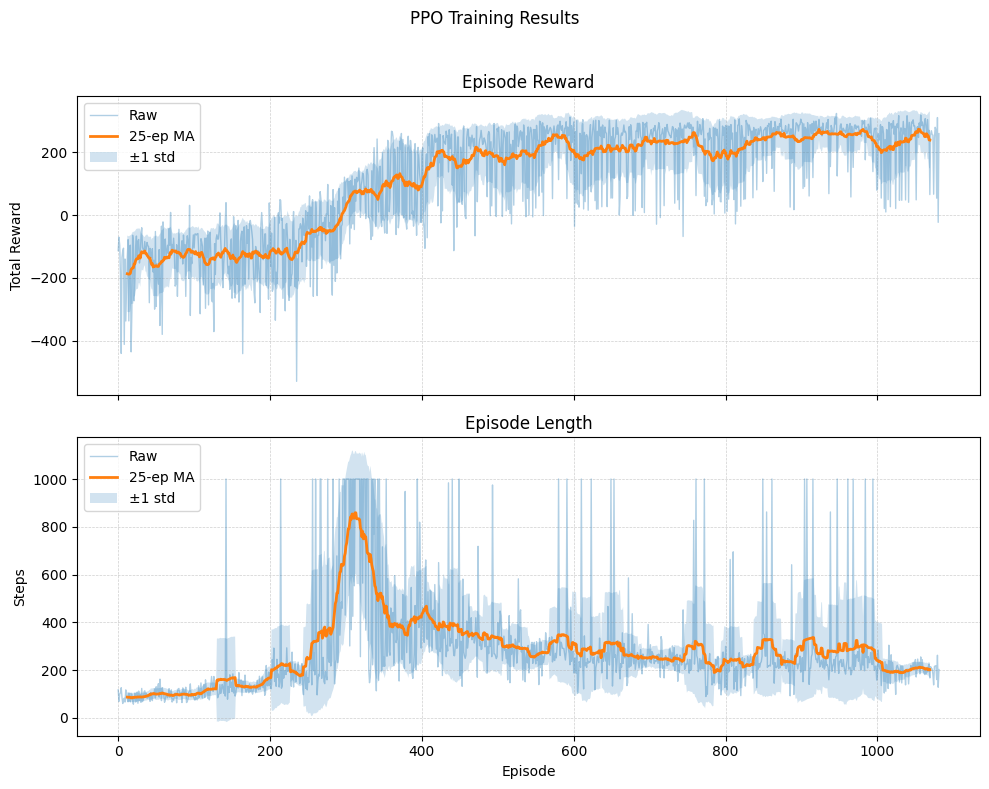

In [12]:
from utils.plot_rl_results import plot_training_statistics

plot_training_statistics(
    episode_rewards=episode_rewards_ppo,
    episode_lengths=episode_lengths_ppo,
    title="PPO Training Results",
    save_path="ppo_training_results",
    window=25,
)

## 10. Save Model

In [13]:
import torch.nn as nn

class PPOActorWrapper(nn.Module):
    """
    Wraps the SB3 PPO actor into a standalone nn.Module that
    maps state (B, 8) -> action_logits (B, 4).

    This lets us reuse save_lunar_model_onnx() without modification.
    """

    def __init__(self, ppo_model):
        super().__init__()
        policy = ppo_model.policy

        # SB3 MlpPolicy has:
        #   policy.mlp_extractor.policy_net  -> shared hidden layers for actor
        #   policy.action_net                -> final Linear(hidden, n_actions)
        self.features_extractor = policy.features_extractor
        self.mlp_extractor_policy = policy.mlp_extractor.policy_net
        self.action_net = policy.action_net

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.features_extractor(x)
        latent = self.mlp_extractor_policy(features)
        action_logits = self.action_net(latent)
        return action_logits


# Extract the actor as a plain nn.Module
actor_module = PPOActorWrapper(ppo_model)

# Save to ONNX using your existing utility
from utils.model_saver import save_lunar_model_onnx

save_path = "training_output_lunar_lander/discrete/ppo_lunar_lander/trained_ppo"

save_lunar_model_onnx(actor_module, save_path)

[torch.onnx] Obtain model graph for `PPOActorWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PPOActorWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✅ Lunar Lander model exported to /home/pnguyen/Workspace/Northeastern_University/ReinforcementLearning_CS_5180/project/LunarLander-TabularTDLearning-To-DeepRL/training_output_lunar_lander/discrete/ppo_lunar_lander/trained_ppo_2026-04-22_12-54.onnx


PosixPath('training_output_lunar_lander/discrete/ppo_lunar_lander/trained_ppo_2026-04-22_12-54.onnx')

## 11. Side-by-Side Comparison with DQN

In [14]:
import json
from pathlib import Path

# ── Load DQN training data ──
dqn_log_path = Path(
    "training_output_lunar_lander/discrete/deep_q_network_lunar_lander/dqn_training_log.json"
)

if dqn_log_path.exists():
    with open(dqn_log_path) as f:
        dqn_log = json.load(f)
    episode_rewards_dqn = dqn_log["episode_rewards"]
    episode_lengths_dqn = dqn_log["episode_lengths"]
    print(f"Loaded DQN data: {len(episode_rewards_dqn)} episodes")
else:
    episode_rewards_dqn = None
    episode_lengths_dqn = None
    print(
        f"DQN log not found at {dqn_log_path}.\n"
        "Run the DQN notebook first and save the training log (see instructions above)."
    )

Loaded DQN data: 1000 episodes


Saved comparison plot to dqn_vs_ppo_comparison.png


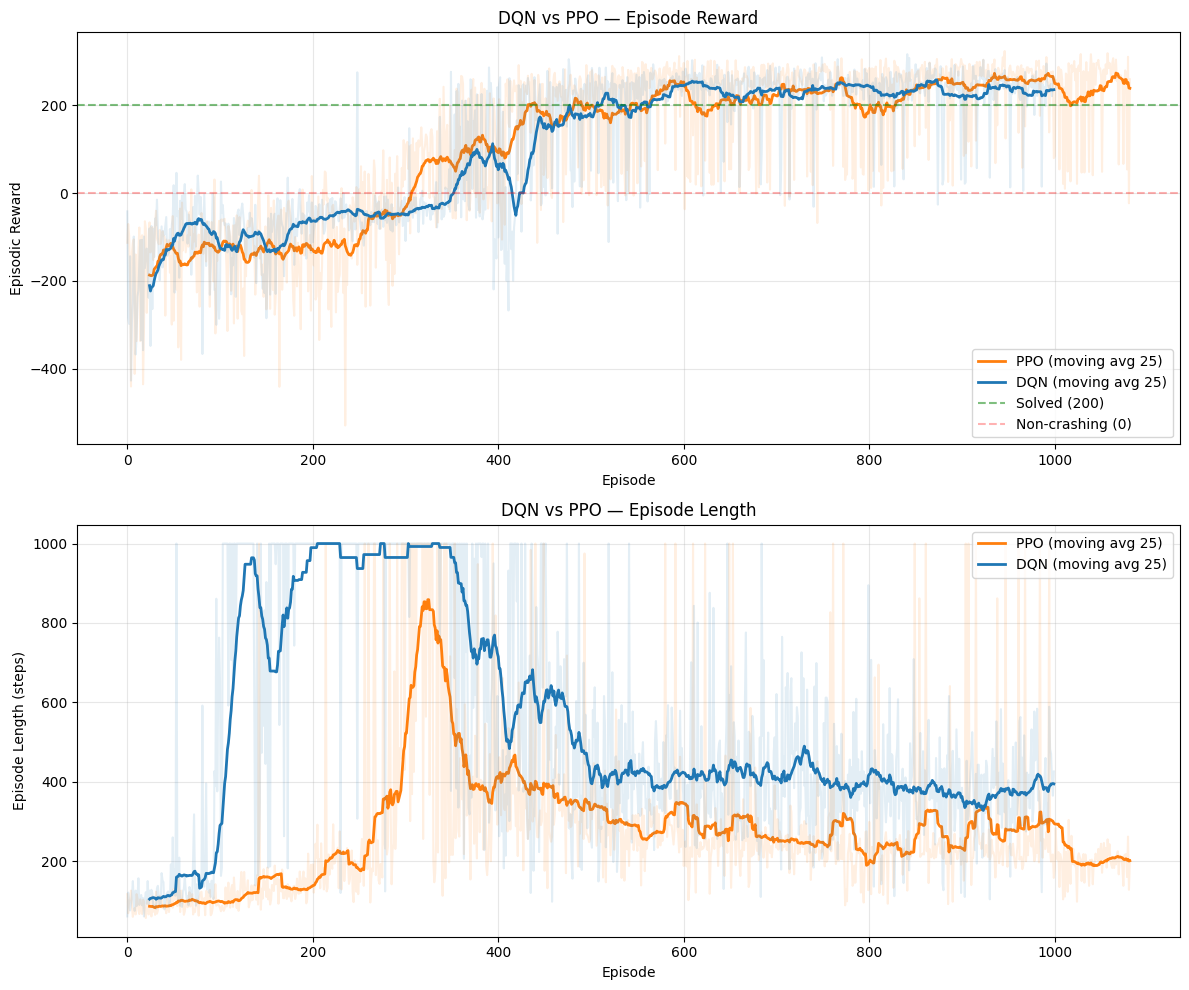

In [15]:
def plot_comparison(
    dqn_rewards: list[float] | None,
    ppo_rewards: list[float],
    dqn_lengths: list[int] | None,
    ppo_lengths: list[int],
    window: int = 25,
    save_path: str | None = "dqn_vs_ppo_comparison",
):
    """
    Plot DQN vs PPO learning curves: episode reward (top) and episode length (bottom).
    """

    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    # ── Helper to plot one metric ──
    def _plot_metric(ax, dqn_data, ppo_data, ylabel, title):
        # PPO
        ppo_ma = np.convolve(ppo_data, np.ones(window) / window, mode="valid")
        ax.plot(ppo_data, alpha=0.12, color="tab:orange")
        ax.plot(
            range(window - 1, len(ppo_data)),
            ppo_ma,
            color="tab:orange",
            linewidth=2,
            label=f"PPO (moving avg {window})",
        )

        # DQN
        if dqn_data is not None:
            dqn_ma = np.convolve(dqn_data, np.ones(window) / window, mode="valid")
            ax.plot(dqn_data, alpha=0.12, color="tab:blue")
            ax.plot(
                range(window - 1, len(dqn_data)),
                dqn_ma,
                color="tab:blue",
                linewidth=2,
                label=f"DQN (moving avg {window})",
            )

        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

    # ── Top: Episode Rewards ──
    _plot_metric(
        axes[0],
        dqn_rewards,
        ppo_rewards,
        ylabel="Episodic Reward",
        title="DQN vs PPO — Episode Reward",
    )
    axes[0].axhline(y=200, color="green", linestyle="--", alpha=0.5, label="Solved (200)")
    axes[0].axhline(y=0, color="red", linestyle="--", alpha=0.3, label="Non-crashing (0)")
    axes[0].legend(loc="lower right")

    # ── Bottom: Episode Lengths ──
    _plot_metric(
        axes[1],
        dqn_lengths,
        ppo_lengths,
        ylabel="Episode Length (steps)",
        title="DQN vs PPO — Episode Length",
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=150, bbox_inches="tight")
        print(f"Saved comparison plot to {save_path}.png")
    plt.show()


plot_comparison(
    dqn_rewards=episode_rewards_dqn,
    ppo_rewards=episode_rewards_ppo,
    dqn_lengths=episode_lengths_dqn,
    ppo_lengths=episode_lengths_ppo,
)

In [16]:
# ── Summary statistics table ──
def print_summary(
    dqn_rewards: list[float] | None,
    ppo_rewards: list[float],
    dqn_lengths: list[int] | None,
    ppo_lengths: list[int],
):
    print(f"{'Metric':<35} {'DQN':>12} {'PPO':>12}")
    print("-" * 60)

    dqn_r = np.array(dqn_rewards) if dqn_rewards else None
    ppo_r = np.array(ppo_rewards)
    dqn_l = np.array(dqn_lengths) if dqn_lengths else None
    ppo_l = np.array(ppo_lengths)

    def fmt(val):
        return f"{val:>12.2f}" if val is not None else f"{'N/A':>12}"

    def fmt_int(val):
        return f"{val:>12d}" if val is not None else f"{'N/A':>12}"

    # Total episodes
    print(f"{'Total episodes':<35} {fmt_int(len(dqn_r) if dqn_r is not None else None)} {fmt_int(len(ppo_r))}")

    # Total timesteps
    print(f"{'Total timesteps':<35} {fmt_int(int(dqn_l.sum()) if dqn_l is not None else None)} {fmt_int(int(ppo_l.sum()))}")

    # Final 25-episode avg reward
    print(f"{'Final 25-ep avg reward':<35} {fmt(dqn_r[-25:].mean() if dqn_r is not None else None)} {fmt(ppo_r[-25:].mean())}")

    # Final 25-episode avg length
    print(f"{'Final 25-ep avg length':<35} {fmt(dqn_l[-25:].mean() if dqn_l is not None else None)} {fmt(ppo_l[-25:].mean())}")

    # Best single episode
    print(f"{'Best episode reward':<35} {fmt(dqn_r.max() if dqn_r is not None else None)} {fmt(ppo_r.max())}")

    # Episode first reaching reward > 200
    def first_above(arr, threshold):
        indices = np.where(arr >= threshold)[0]
        return int(indices[0]) + 1 if len(indices) > 0 else None

    print(f"{'First episode reward > 0':<35} {fmt_int(first_above(dqn_r, 0) if dqn_r is not None else None)} {fmt_int(first_above(ppo_r, 0))}")
    print(f"{'First episode reward > 200':<35} {fmt_int(first_above(dqn_r, 200) if dqn_r is not None else None)} {fmt_int(first_above(ppo_r, 200))}")


print_summary(
    dqn_rewards=episode_rewards_dqn,
    ppo_rewards=episode_rewards_ppo,
    dqn_lengths=episode_lengths_dqn,
    ppo_lengths=episode_lengths_ppo,
)

Metric                                       DQN          PPO
------------------------------------------------------------
Total episodes                              1000         1082
Total timesteps                           540650       300855
Final 25-ep avg reward                    235.66       238.98
Final 25-ep avg length                    394.80       201.24
Best episode reward                       316.54       323.74
First episode reward > 0                      51           70
First episode reward > 200                   249          338
